# Calculations

## Importing modules

In [1]:
# Import modules
import pandas as pd
import matplotlib.pyplot as plt
from fitter import Fitter
from scipy import stats
import numpy as np

## Loading data


In [2]:
#Loading all sheets
ex2 = pd.read_excel("../MillerPainTreatmentCenterData.xlsx", sheet_name = "Exhibit2")
ex3 = pd.read_excel("../MillerPainTreatmentCenterData.xlsx", sheet_name = "Exhibit3")
ex4 = pd.read_excel("../MillerPainTreatmentCenterData.xlsx", sheet_name = "Exhibit4")
ex6 = pd.read_excel("../MillerPainTreatmentCenterData.xlsx", sheet_name = "Exhibit6")
ex7 = pd.read_excel("../MillerPainTreatmentCenterData.xlsx", sheet_name = "Exhibit7")

/Library/Frameworks/Python.framework/Versions/3.13/lib/python3.13/site-packages/openpyxl/worksheet/_reader.py:329: UserWarning: Unknown extension is not supported and will be removed
  warn(msg)
/Library/Frameworks/Python.framework/Versions/3.13/lib/python3.13/site-packages/openpyxl/worksheet/_reader.py:329: UserWarning: Unknown extension is not supported and will be removed
  warn(msg)
/Library/Frameworks/Python.framework/Versions/3.13/lib/python3.13/site-packages/openpyxl/worksheet/_reader.py:329: UserWarning: Unknown extension is not supported and will be removed
  warn(msg)
/Library/Frameworks/Python.framework/Versions/3.13/lib/python3.13/site-packages/openpyxl/worksheet/_reader.py:329: UserWarning: Unknown extension is not supported and will be removed
  warn(msg)
/Library/Frameworks/Python.framework/Versions/3.13/lib/python3.13/site-packages/openpyxl/worksheet/_reader.py:329: UserWarning: Unknown extension is not supported and will be removed
  warn(msg)


## Input analysis

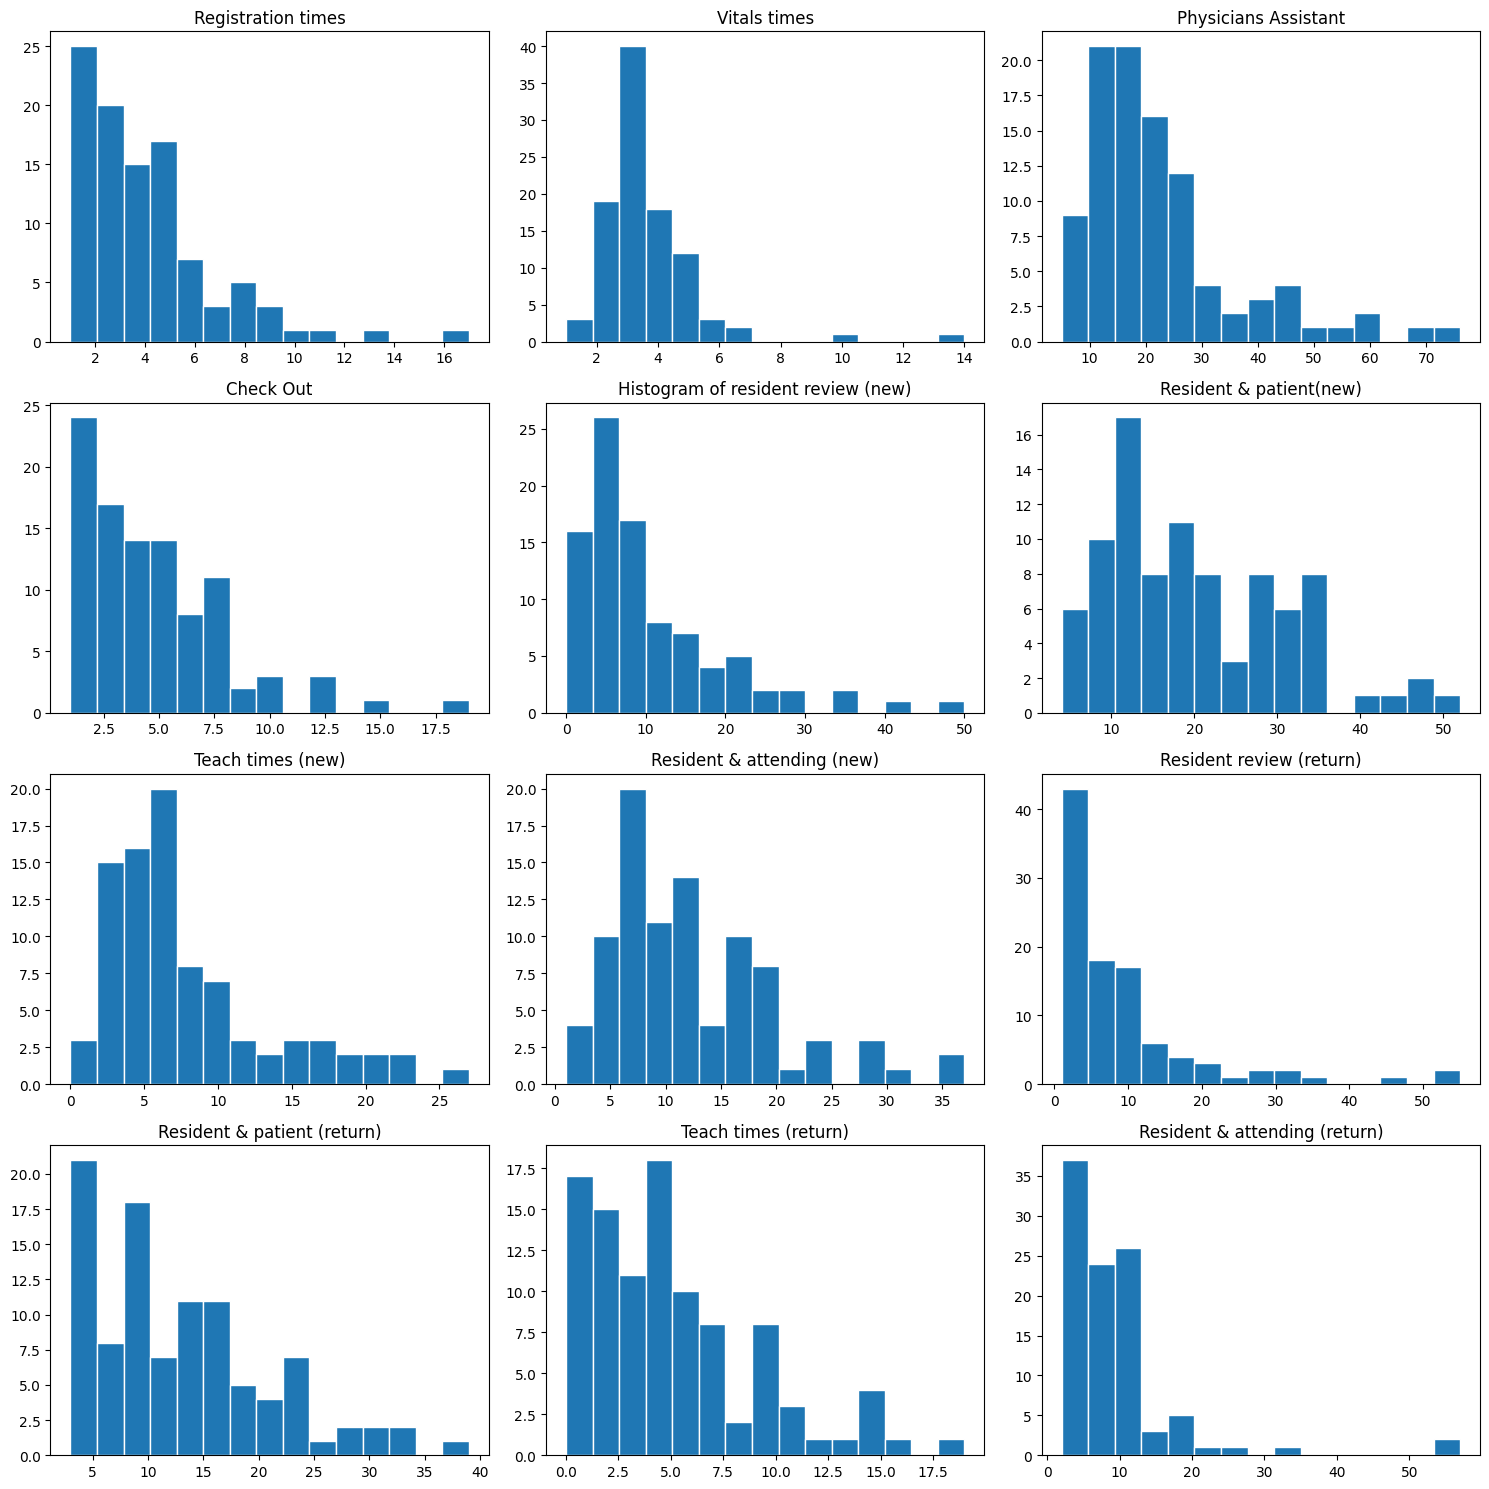

In [3]:
# Histogram of variables
fig, ax = plt.subplots(4, 3, figsize=(15, 15))

ax[0][0].hist(ex2["Registration"], bins=15, edgecolor='white')
ax[0][0].set_title("Registration times")

ax[0][1].hist(ex2["Vitals"], bins=15, edgecolor='white')
ax[0][1].set_title("Vitals times")

ax[0][2].hist(ex2["Physicians Assistant"], bins=15, edgecolor='white')
ax[0][2].set_title("Physicians Assistant")

ax[1][0].hist(ex2["Check Out"], bins=15, edgecolor='white')
ax[1][0].set_title("Check Out")

ax[1][1].hist(ex6["Resident Review"], bins=15, edgecolor='white')
ax[1][1].set_title("Histogram of resident review (new)")

ax[1][2].hist(ex6["Resident & Patient"], bins=15, edgecolor='white')
ax[1][2].set_title("Resident & patient(new)")

ax[2][0].hist(ex6["Teach"], bins=15, edgecolor='white')
ax[2][0].set_title("Teach times (new)")

ax[2][1].hist(ex6["Resident & Attending"], bins=15, edgecolor='white')
ax[2][1].set_title("Resident & attending (new)")

ax[2][2].hist(ex7["Resident Review"], bins=15, edgecolor='white')
ax[2][2].set_title("Resident review (return)")

ax[3][0].hist(ex7["Resident & Patient"], bins=15, edgecolor='white')
ax[3][0].set_title("Resident & patient (return)")

ax[3][1].hist(ex7["Teach"], bins=15, edgecolor='white')
ax[3][1].set_title("Teach times (return)")

ax[3][2].hist(ex7["Resident & Attending"], bins=15, edgecolor='white')
ax[3][2].set_title("Resident & attending (return)")

plt.tight_layout()
plt.show()

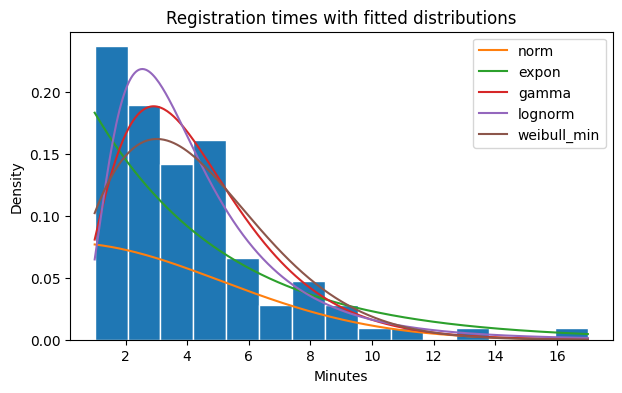

In [4]:
#Registration time
fig, ax = plt.subplots(figsize=(7, 4))

data = ex2['Registration'].values
dists = {
    'norm': stats.norm, 
    'expon': stats.expon, 
    'gamma': stats.gamma, 
    'lognorm': stats.lognorm, 
    'weibull_min': stats.weibull_min
}

x = np.linspace(data.min(), data.max(), 300)

ax.hist(data, bins = 15, density = True, edgecolor = 'white')

for distname, dist in dists.items():
    params = dist.fit(data, floc = 0)
    ax.plot(x, dist.pdf(x, *params), label = distname)

ax.set_title("Registration times with fitted distributions")
ax.set_xlabel("Minutes")
ax.set_ylabel("Density")

ax.legend()
plt.show()

By the shape of the histograms, and as our data contains time (minutes), we can assume that distributions such as the ones below could suit the process.

In [5]:
#Dictionary for all variables and their data
variables = {
    'Registration'                 : ex2['Registration'].dropna().values,
    'Vitals'                       : ex2['Vitals'].dropna().values,
    'Physicians Assistant'         : ex2['Physicians Assistant'].dropna().values,
    'Check Out'                    : ex2['Check Out'].dropna().values,
    'Resident Review (New)'        : ex6['Resident Review'].replace(0, np.nan).dropna().values,
    'Resident & Patient (New)'     : ex6['Resident & Patient'].dropna().values,
    'Teach (New)'                  : ex6['Teach'].replace(0, np.nan).dropna().values,
    'Resident & Attending (New)'   : ex6['Resident & Attending'].dropna().values,
    'Resident Review (Return)'     : ex7['Resident Review'].dropna().values,
    'Resident & Patient (Return)'  : ex7['Resident & Patient'].dropna().values,
    'Teach (Return)'               : ex7['Teach'].replace(0, np.nan).dropna().values,
    'Resident & Attending (Return)': ex7['Resident & Attending'].dropna().values,
}

In [6]:
#Candiate distributions after visual examination
dists = {
    'expon'      : stats.expon,
    'gamma'      : stats.gamma,
    'lognorm'    : stats.lognorm,
    'weibull_min': stats.weibull_min,
}

In [7]:
for var, data in variables.items():
    opt_D, opt_p, opt_name, opt_params = 999, 0, None, None
    
    print(f"\n{'='*34}")
    print(f"{var}")
    print(f"{'='*34}")
    print(f"{'Distribution':<14} {'KS':>8} {'p-value':>10}")
    print("-"*34)
    
    for distname, dist in dists.items():
        try:
            params = dist.fit(data, floc = 0)
            D, p = stats.kstest(data, dist.cdf, args = params)
            if p > 0.05 and D < opt_D:
                opt_D, opt_p, opt_name, opt_params = D, p, distname, params
            print(f"{distname:<14} {D:>8.4f} {p:>10.4f}")
        except:
            print(f"{distname:<14} {'FAILED':>8}")
    
    #For vitals, as it has no p-value over 0.05
    if opt_name:
        print(f"\nOptimal distribution: {opt_name}") 
        print(f"KS Statistic = {opt_D:.4f}")
        print(f"P-value = {opt_p:.4f}")
        print(f"Params: {np.round(opt_params, 4)}")
    else:
        print(f"\nNo distribution passed p > 0.05")
        print("Choose distribution with best KS")


Registration
Distribution         KS    p-value
----------------------------------
expon            0.2990     0.0000
gamma            0.1129     0.1481
lognorm          0.1199     0.1068
weibull_min      0.1318     0.0583

Optimal distribution: gamma
KS Statistic = 0.1129
P-value = 0.1481
Params: [3.0519 0.     1.4199]

Vitals
Distribution         KS    p-value
----------------------------------
expon            0.4027     0.0000
gamma            0.2162     0.0002
lognorm          0.2128     0.0002
weibull_min      0.2028     0.0005

No distribution passed p > 0.05
Choose distribution with best KS

Physicians Assistant
Distribution         KS    p-value
----------------------------------
expon            0.2772     0.0000
gamma            0.1048     0.2162
lognorm          0.0661     0.7602
weibull_min      0.1238     0.0910

Optimal distribution: lognorm
KS Statistic = 0.0661
P-value = 0.7602
Params: [ 0.5405  0.     19.4511]

Check Out
Distribution         KS    p-value
-----------

## Output Analysis

In [8]:
#Data from .dat files of models

asis = pd.read_csv('../JaamSim/AS-IS/AS-IS.dat', sep = '\t').iloc[:-1].iloc[:, 2].values
scheduling = pd.read_csv('../JaamSim/TO-BE Scheduling/TO-BE_Scheduling.dat', sep = '\t').iloc[:-1].iloc[:, 2].values
preprocessing = pd.read_csv('../JaamSim/TO-BE Pre-processing/TO-BE_Pre-processing.dat', sep = '\t').iloc[:-1].iloc[:, 2].values
combined = pd.read_csv('../JaamSim/TO-BE Combined/TO-BE_Combined.dat', sep = '\t').iloc[:-1].iloc[:, 2].values

simulations = {
    "AS-IS":                   asis,
    "TO-BE 1: Scheduling":     scheduling,    
    "TO-BE 2: Pre-processing": preprocessing,
    "TO-BE 3: Combined":       combined,
}

n      = 30
alpha  = 0.05
t_crit = stats.t.ppf(1 - alpha / 2, df = n - 1)

### Table 1 - Confidence intervals

In [9]:
#Mean, standard deviation and confidence intervals
results = {}

for name, data in simulations.items():
    mean = np.mean(data)
    std = np.std(data, ddof = 1)
    se = std / np.sqrt(n)
    low = mean - t_crit * se
    high = mean + t_crit * se
    results[name] = {"Mean": mean, "Std": std, "CI Lower": low, "CI upper": high}

table1 = pd.DataFrame(results).T.round(3)
print(table1)

                           Mean     Std  CI Lower  CI upper
AS-IS                    62.011  13.239    57.068    66.955
TO-BE 1: Scheduling      55.297  11.079    51.160    59.434
TO-BE 2: Pre-processing  56.540  12.835    51.748    61.333
TO-BE 3: Combined        49.902   9.705    46.278    53.526


### Table 2 - T-test

In [10]:
paired_results = {}

for name, data in list(simulations.items())[1:]:
    d     = np.array(data) - np.array(asis)
    dmean = np.mean(d)
    dstd  = np.std(d, ddof = 1)
    dse   = dstd / np.sqrt(n)
    tstat = dmean / dse
    pval  = 2 * stats.t.cdf(-abs(tstat), df = n - 1)
    low    = dmean - t_crit * dse
    high    = dmean + t_crit * dse
    paired_results[name + " vs AS-IS"] = {
        "Mean diff": dmean,
        "CI lower": low,
        "CI upper": high,
        "t-stat": tstat,
        "p-value": pval
    }

table2 = pd.DataFrame(paired_results).T.round(2)
print(table2)

                                  Mean diff  CI lower  CI upper  t-stat  \
TO-BE 1: Scheduling vs AS-IS          -6.71     -8.12     -5.31   -9.80   
TO-BE 2: Pre-processing vs AS-IS      -5.47     -6.76     -4.19   -8.71   
TO-BE 3: Combined vs AS-IS           -12.11    -14.41     -9.81  -10.76   

                                  p-value  
TO-BE 1: Scheduling vs AS-IS          0.0  
TO-BE 2: Pre-processing vs AS-IS      0.0  
TO-BE 3: Combined vs AS-IS            0.0  


### AI

AI has been used to debug and improve the code used.